In [1]:
import matplotlib.pyplot as plt
import numpy as np

from geodesiq import *

# Double quantum dot model

In [2]:
def dqd_hamiltonian(eps, U, tc, Ez, dEz, dEx):
    ham = np.array([[U - eps, 0, -tc, tc, 0], [0, Ez, dEx, -dEx, 0], [-tc, dEx, dEz, 0, dEx], [tc, -dEx, 0, -dEz, -dEx],
        [0, 0, dEx, -dEx, -Ez]])
    return ham


dqd_model = Hamiltonian(dqd_hamiltonian)

# ----- Set system and control parameters -----
alpha, beta = 2, 2

U, tc, Ez, dEz, dEx = 10, 1, .9, .1, .01
eps0, epsf = 15, 0

dqd_model.set_parameters(U=U, tc=tc, Ez=Ez, dEz=dEz, dEx=dEx)
dqd_model.set_control(control_name='eps', pulse_initial=eps0, pulse_final=epsf, initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
dqd_model.solve_problem(pulse_accuracy=int(1000))

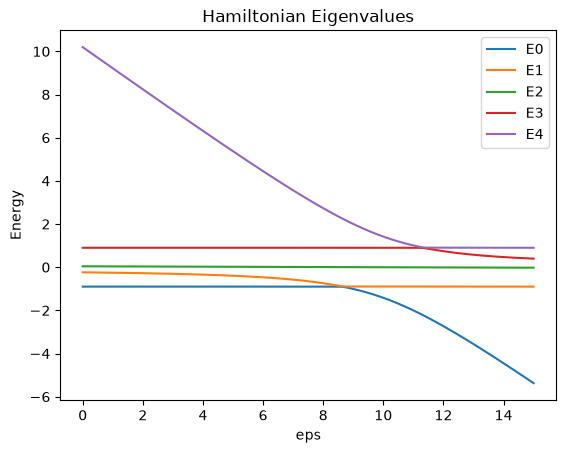

In [3]:
dqd_model.plot_eigenvalues();

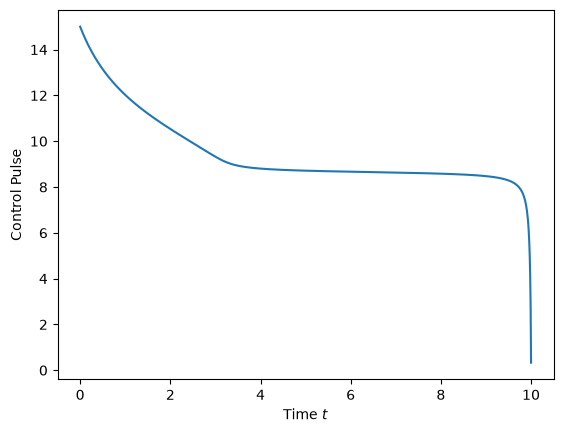

In [4]:
pulse = dqd_model.synthesize_pulse(duration=10)
pulse.plot_pulse();

# Time dynamics

In [5]:
def fidelity_vs_time(durations, hamiltonian, alpha=2, beta=2):
    hamiltonian.set_control(alpha=alpha, beta=beta)
    hamiltonian.solve_problem(pulse_accuracy=int(1000))

    fidelities = []
    for duration in durations:
        dynamics = Dynamics(duration=duration, hamiltonian=hamiltonian)
        fidelities.append(dynamics.state_fidelity())

    return np.array(fidelities)

In [6]:
durations = np.linspace(0, 1000, 200)

# Takes roughly between 1 and 2 minutes to run locally
fidelities_geometric = fidelity_vs_time(durations, dqd_model, alpha=2, beta=2)
fidelities_faquad = fidelity_vs_time(durations, dqd_model, alpha=4, beta=2)

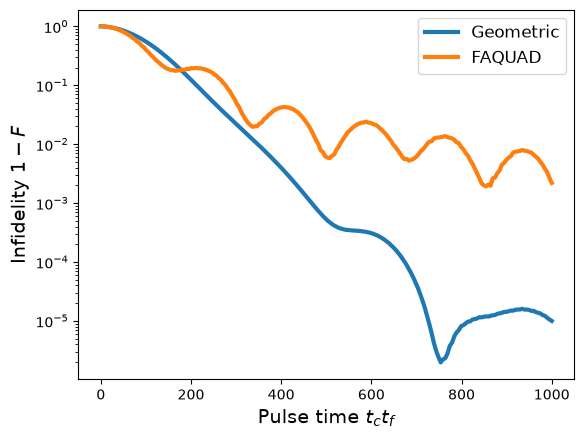

In [7]:
plt.plot(durations, 1 - fidelities_geometric, label='Geometric', lw=3)
plt.plot(durations, 1 - fidelities_faquad, label='FAQUAD', lw=3)
plt.yscale('log')
plt.ylabel('Infidelity $1-F$', fontsize=14)
plt.xlabel('Pulse time $t_c t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show();

# $(\alpha,\beta;\hat{\alpha}, \hat{\beta})$ fidelity sweep: pure adiabatic evolution

In [8]:
# joblib is an additional Python package for parallel computing
import itertools

from joblib import Parallel, delayed

In [9]:
def optimal_fidelity_time_map(durations, hamiltonian, alphas, betas, n_jobs=-1):
    """
    Function that computes the fidelity map for a range of alpha and beta values over a range of durations.
    The function relies on the definition of fidelity_vs_time() from above.
    """
    results = Parallel(n_jobs=n_jobs)(
        delayed(fidelity_vs_time)(durations, hamiltonian, alpha=alpha, beta=beta) for alpha, beta in
        itertools.product(alphas, betas))

    fidelities = np.array(results).reshape(len(alphas), len(betas), len(durations))

    max_fidelities = np.max(fidelities, axis=2)
    best_times = durations[np.argmax(fidelities, axis=2)]

    return max_fidelities, best_times

In [15]:
durations_2d = np.linspace(0, 1000, 100)

alphas = np.linspace(0, 4, 7)
betas = np.linspace(0, 4, 7)

optimal_fidelities, best_times = optimal_fidelity_time_map(durations_2d, dqd_model, alphas, betas)

/mnt/c/Users/vawi76si/OneDrive - Universität Augsburg/Projects/geodesiq-control/src/geodesiq/dynamics.py:115: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your function to the pythonic signature f(t, **kwargs) to maintain compatibility.
  H_T = qt.QobjEvo(self._get_ham, args={"pulse": self._control_sol, "times": self._pulse_times})
/mnt/c/Users/vawi76si/OneDrive - Universität Augsburg/Projects/geodesiq-control/src/geodesiq/dynamics.py:115: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your function to the pythonic signature f(t, **kwargs) to maintain compatibility.
  H_T = qt.QobjEvo(self._get_ham, args={"pulse": self._control_sol, "times": self._pulse_times})
/mnt/c/Users/vawi76si/OneDrive - Universität Augsburg/Projects/geodesiq-control/src/geodesiq/dynamics.py:115: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your f

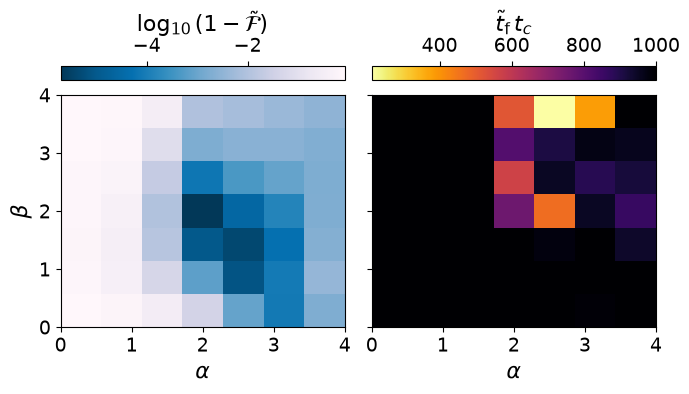

In [16]:
fontsizes = 14
fontsize_label = 16
colorbar_loc = 'top'
cmap_coloring_fid = 'PuBu_r'
extent = [min(alphas), max(alphas), min(betas), max(betas)]

fig, axs = plt.subplots(1, 2, figsize=(7, 4), sharey=True)

# --- Left Plot: Optimal Fidelity ---
fidelity_error = np.log10(1 - optimal_fidelities.T)

im0 = axs[0].imshow(fidelity_error, origin='lower', aspect='auto', interpolation='none', extent=extent,
    cmap=cmap_coloring_fid)
axs[0].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[0].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[0].tick_params(labelsize=fontsizes)

cbar0 = plt.colorbar(im0, ax=axs[0], location=colorbar_loc, pad=0.05)
cbar0.set_label(r'$\log_{10}(1 - \tilde{\mathcal{F}})$', size=fontsize_label)
cbar0.ax.tick_params(labelsize=fontsizes)

# --- Right Plot: Best Times ---
im1 = axs[1].imshow(best_times.T, origin='lower', aspect='auto', interpolation='none', extent=extent, cmap='inferno_r')
axs[1].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[1].tick_params(labelsize=fontsizes)

cbar1 = plt.colorbar(im1, ax=axs[1], location=colorbar_loc, pad=0.05)
cbar1.set_label(r'$\tilde{t}_\text{f}\,t_c$', size=fontsize_label)
cbar1.ax.tick_params(labelsize=fontsizes)

plt.tight_layout()
plt.show();

# Combined plotting (first run both optimizations individually)

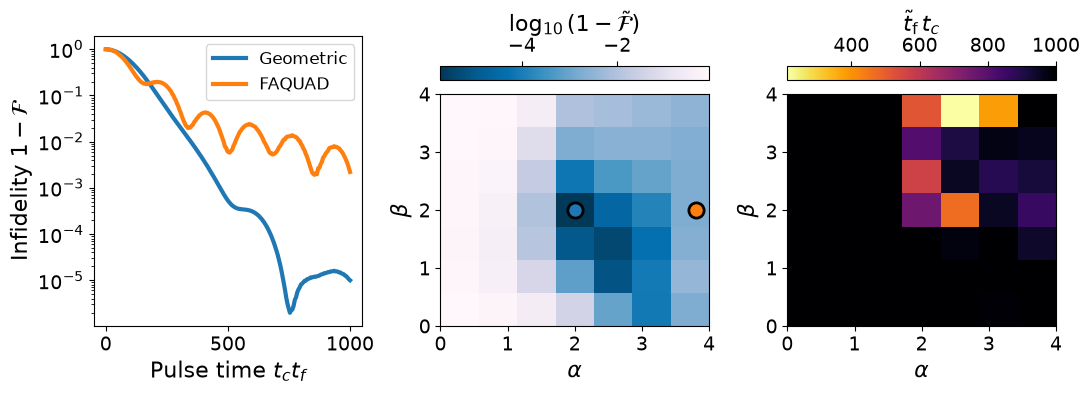

In [18]:
fontsizes = 14
fontsize_label = 16
colorbar_loc = 'top'
cmap_coloring_fid = 'PuBu_r'
extent = [min(alphas), max(alphas), min(betas), max(betas)]

fig, axs = plt.subplots(1, 3, figsize=(11, 4))

axs[0].plot(durations, 1 - fidelities_geometric, label='Geometric', lw=3)
axs[0].plot(durations, 1 - fidelities_faquad, label='FAQUAD', lw=3)
axs[0].set_yscale('log')
axs[0].set_ylabel(r'Infidelity $1-\mathcal{F}$', fontsize=fontsize_label)
axs[0].set_xlabel('Pulse time $t_c t_f$', fontsize=fontsize_label)
axs[0].tick_params(labelsize=fontsizes)
axs[0].legend(fontsize=12)

infidelity_opt = np.log10(1 - optimal_fidelities.T)

im1 = axs[1].imshow(infidelity_opt, origin='lower', aspect='auto', interpolation='none', extent=extent,
    cmap=cmap_coloring_fid)
axs[1].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[1].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[1].tick_params(labelsize=fontsizes)

axs[1].scatter(2, 2, s=120, label='Geometric', edgecolor='black', linewidths=2)
axs[1].scatter(3.8, 2, s=120, label='FAQUAD', edgecolor='black', linewidths=2)

cbar1 = plt.colorbar(im1, ax=axs[1], location=colorbar_loc, pad=0.05)
cbar1.set_label(r'$\log_{10}(1 - \tilde{\mathcal{F}})$', size=fontsize_label)
cbar1.ax.tick_params(labelsize=fontsizes)

im2 = axs[2].imshow(best_times.T, origin='lower', aspect='auto', interpolation='none', extent=extent, cmap='inferno_r')
axs[2].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[2].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[2].tick_params(labelsize=fontsizes)

cbar2 = plt.colorbar(im2, ax=axs[2], location=colorbar_loc, pad=0.05)
cbar2.set_label(r'$\tilde{t}_\text{f}\,t_c$', size=fontsize_label)
cbar2.ax.tick_params(labelsize=fontsizes)

plt.tight_layout()
plt.show();